# Bài tập về nhà Kmeans

## Mục tiêu 
- Tự viết lại code cho giải thuật K-means
- Hiểu sâu hơn giải thuật K-means qua việc tự viết lại code
- Ứng dụng mô hình tự viết vào các bài toán đã ra trên lớp

## Dữ liệu 

Giống dữ liệu của bài thực hành trên lớp (dữ liệu sinh ngẫu nhiên bằng sklearn và ảnh bird_small.png)

## Yêu cầu

Code K-means tự viết cho kết quả tương đương (không cần giống hệt) với giải thuật của thư viện sklearn khi áp dụng cho dữ liệu sinh ngẫu nhiên và dữ liệu ảnh.

# Các bước làm

## Các thư viện sử dụng 

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
from sklearn.metrics.pairwise import euclidean_distances
from IPython.display import Image, display
%matplotlib inline

## Chuẩn bị dữ liệu 
- Sinh dữ liệu ngẫu nhiên n_samples = 100 tương đương 100 điểm 
    - random_state: biến cố định hàm random - để các điểm sinh ngẫu nhiên giống nhau giữa các máy tính
    
- Mỗi điểm dữ liệu có 2 chiều 

In [2]:
n_samples = 100
random_state = 170
center_points = [[1, 1], [-1, -1], [1, -1]] # sinh ngẫu nhiên các điểm xung quanh vị trí tâm cố định 
#center_points = 3                           # tâm cụm được chọn ngẫu nhiên

X, y = make_blobs(n_samples=n_samples, random_state=random_state, centers=center_points, cluster_std=0.6)
print("Số chiều dữ liệu: ", X.shape, y.shape)
print("5 điểm dữ liệu đầu tiên: \n", X[:6])

Số chiều dữ liệu:  (100, 2) (100,)
5 điểm dữ liệu đầu tiên: 
 [[ 1.26241305  0.94872541]
 [-0.39743873 -1.18567406]
 [ 1.35081331  0.48041993]
 [ 1.21219555  0.98929291]
 [-0.75344338 -1.09784774]
 [ 2.67199591 -0.16659988]]


**Vẽ các điểm ảnh sử dụng matplotlib**

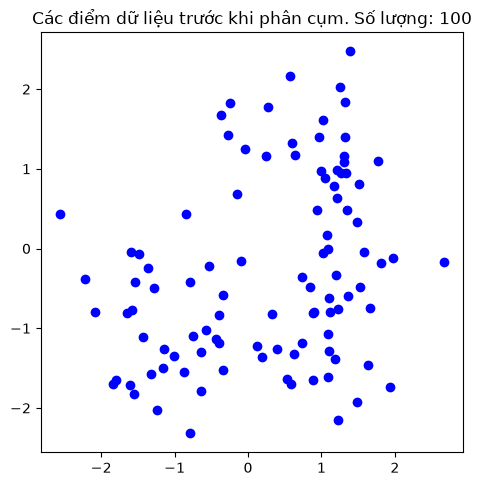

In [3]:
plt.figure(figsize=(12, 12))
plt.subplot(221)
plt.scatter(X[:, 0], X[:, 1], c='blue') # c là tham số chọn màu sắc, có thể truyền vào string hoặc số id 1,2,3 ...
plt.title("Các điểm dữ liệu trước khi phân cụm. Số lượng: {}".format(n_samples))
plt.show()

## Tự xây dựng giải thuật K-means:

Viết code cho giải thuật K-means tại mục này

In [4]:
class MyKMeans:
    """K-means tự cài đặt.
    - Khởi tạo tâm cụm bằng k-means++
    - Lặp 2 bước: gán nhãn (E-step) và cập nhật tâm cụm (M-step) đến khi hội tụ
    - Chạy n_init lần với các khởi tạo khác nhau, giữ lại kết quả có inertia nhỏ nhất
    """

    def __init__(self, n_clusters=8, max_iter=300, tol=1e-4, n_init=10, random_state=None):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.tol = tol
        self.n_init = n_init
        self.random_state = random_state

    def _init_centers(self, X, rng):
        # k-means++: tâm đầu tiên chọn ngẫu nhiên, các tâm sau được chọn với xác suất
        # tỉ lệ với bình phương khoảng cách tới tâm gần nhất đã chọn
        n_samples = X.shape[0]
        centers = [X[rng.integers(n_samples)]]
        for _ in range(1, self.n_clusters):
            d2 = euclidean_distances(X, np.array(centers), squared=True).min(axis=1)
            centers.append(X[rng.choice(n_samples, p=d2 / d2.sum())])
        return np.array(centers)

    def _assign_labels(self, X, centers):
        # gán mỗi điểm vào tâm cụm gần nhất
        d2 = euclidean_distances(X, centers, squared=True)
        labels = d2.argmin(axis=1)
        inertia = d2[np.arange(X.shape[0]), labels].sum()
        return labels, inertia

    def _update_centers(self, X, labels, old_centers):
        # tâm cụm mới = trung bình các điểm thuộc cụm (cụm rỗng giữ nguyên tâm cũ)
        centers = old_centers.copy()
        for j in range(self.n_clusters):
            members = X[labels == j]
            if len(members) > 0:
                centers[j] = members.mean(axis=0)
        return centers

    def _single_run(self, X, rng, tol):
        centers = self._init_centers(X, rng)
        for n_iter in range(1, self.max_iter + 1):
            labels, _ = self._assign_labels(X, centers)
            new_centers = self._update_centers(X, labels, centers)
            shift = ((new_centers - centers) ** 2).sum()
            centers = new_centers
            if shift <= tol:
                break
        labels, inertia = self._assign_labels(X, centers)
        return centers, labels, inertia, n_iter

    def fit(self, X):
        X = np.asarray(X, dtype=float)
        rng = np.random.default_rng(self.random_state)
        tol = self.tol * np.mean(np.var(X, axis=0))  # tol tương đối theo phương sai dữ liệu (giống sklearn)
        best = None
        for _ in range(self.n_init):
            run = self._single_run(X, rng, tol)
            if best is None or run[2] < best[2]:
                best = run
        self.cluster_centers_, self.labels_, self.inertia_, self.n_iter_ = best
        return self

    def predict(self, X):
        return self._assign_labels(np.asarray(X, dtype=float), self.cluster_centers_)[0]

    def fit_predict(self, X):
        return self.fit(X).labels_

## Kiểm tra giải thuật K-means tự viết cho dữ liệu sinh ngẫu nhiên

- Áp dụng giải thuật K-means tự viết cho tập dữ liệu đã sinh ngẫu nhiên ở trên
- Quan sát kết quả và so sánh với giải thuật của sklearn

Tâm cụm - K-means tự viết:
 [[-1.13949326 -0.97100768]
 [ 0.88823619  1.19442485]
 [ 1.11177838 -0.94555162]]
Tâm cụm - sklearn:
 [[-1.13949326 -0.97100768]
 [ 0.88823619  1.19442485]
 [ 1.11177838 -0.94555162]]
Inertia - tự viết: 70.326563 | sklearn: 70.326563
Số vòng lặp (lần chạy tốt nhất) - tự viết: 3
Adjusted Rand Index giữa 2 cách phân cụm: 1.0


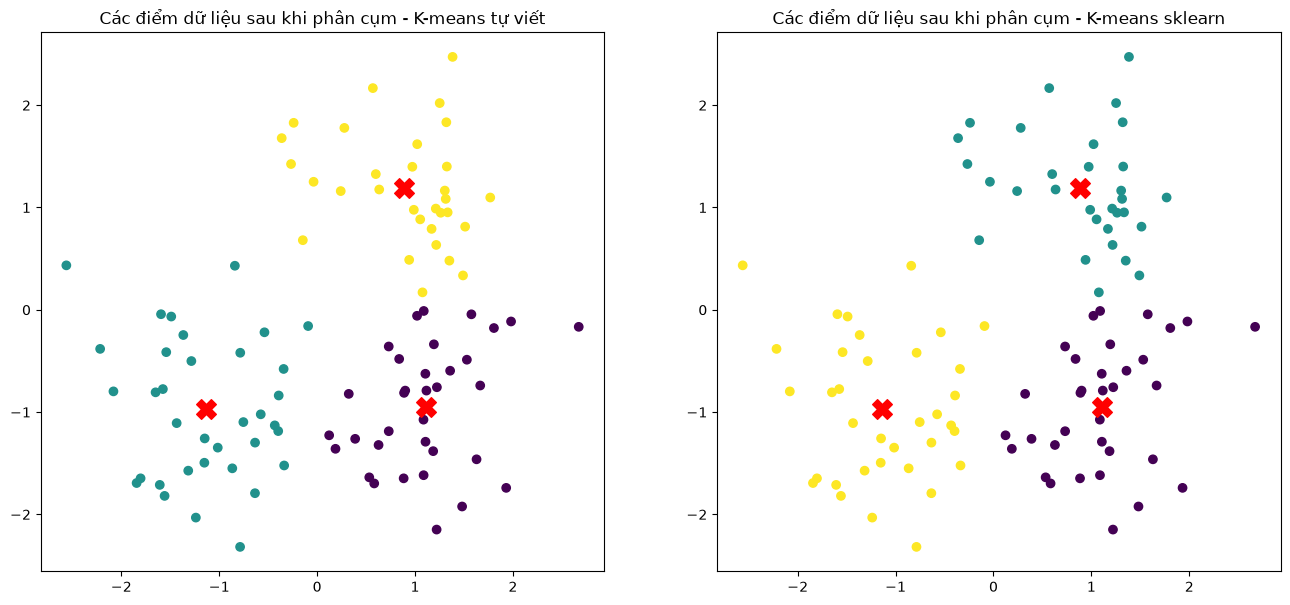

In [5]:
from sklearn.metrics import adjusted_rand_score

k_cluster = 3
# K-means tự viết
my_model = MyKMeans(n_clusters=k_cluster, random_state=random_state).fit(X)
my_pred = my_model.predict(X)
# K-means của sklearn
sk_model = KMeans(n_clusters=k_cluster, random_state=random_state, n_init=10).fit(X)
sk_pred = sk_model.predict(X)

print("Tâm cụm - K-means tự viết:\n", my_model.cluster_centers_[np.argsort(my_model.cluster_centers_[:, 0])])
print("Tâm cụm - sklearn:\n", sk_model.cluster_centers_[np.argsort(sk_model.cluster_centers_[:, 0])])
print("Inertia - tự viết: {:.6f} | sklearn: {:.6f}".format(my_model.inertia_, sk_model.inertia_))
print("Số vòng lặp (lần chạy tốt nhất) - tự viết:", my_model.n_iter_)
print("Adjusted Rand Index giữa 2 cách phân cụm:", adjusted_rand_score(my_pred, sk_pred))

plt.figure(figsize=(16, 7))
for i, (name, pred, ctr) in enumerate([("K-means tự viết", my_pred, my_model.cluster_centers_),
                                        ("K-means sklearn", sk_pred, sk_model.cluster_centers_)]):
    plt.subplot(1, 2, i + 1)
    plt.scatter(X[:, 0], X[:, 1], c=pred)
    plt.scatter(ctr[:, 0], ctr[:, 1], c='red', marker='X', s=200)
    plt.title("Các điểm dữ liệu sau khi phân cụm - " + name)
plt.show()

**Nhận xét:** tâm cụm và inertia của K-means tự viết trùng với sklearn (sai khác chỉ ở thứ tự nhãn cụm),
Adjusted Rand Index = 1.0 nghĩa là hai cách phân cụm giống hệt nhau.

## Ứng dụng K-means tự viết vào nén ảnh 

### Thư viện sử dụng - hỗ trợ hình ảnh 

In [6]:
from skimage import io
from sklearn.cluster import KMeans
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as image
from IPython.display import Image, display

### Đọc dữ liệu hình ảnh
- Mỗi điểm ảnh là 1 mẫu quan sát 
- Phân cụm tập dữ liệu (tập các điểm ảnh) về k nhãn

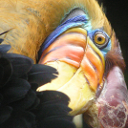

Số chiều của dữ liệu hình ảnh:  (16384, 3)
Tổng số điểm ảnh là:  16384
Mỗi điểm ảnh có số chiều =  3


In [7]:
path_img = 'bird_small.png'
display(Image(path_img, width=250, unconfined=True))
img = io.imread(path_img)
data_img = (img / 255.0).reshape(-1,img.shape[2]) # chuyển ma trận 128x128x3 về mảng 2 chiều 
img_shape = img.shape                    

print("Số chiều của dữ liệu hình ảnh: ", data_img.shape)
print("Tổng số điểm ảnh là: ", data_img.shape[0])
print("Mỗi điểm ảnh có số chiều = ", data_img.shape[1])

### Nén ảnh bằng giải thuật K-means tự viết

- Tạo file nén ảnh bằng giải thuật K-means tự viết
- Hiển thị kết quả của giải thuật tự viết và giải thuật của sklearn để so sánh


In [8]:
n_color = 10

# K-means tự viết
my_img_model = MyKMeans(n_clusters=n_color, random_state=random_state).fit(data_img)
img_128 = my_img_model.cluster_centers_[my_img_model.labels_].reshape(img_shape)
image.imsave('img_128.png', img_128)

# K-means của sklearn
sk_img_model = KMeans(n_clusters=n_color, random_state=random_state, n_init=10).fit(data_img)
img128 = sk_img_model.cluster_centers_[sk_img_model.labels_].reshape(img_shape)
image.imsave('img128.png', img128)

print("Inertia - tự viết: {:.4f} | sklearn: {:.4f}".format(my_img_model.inertia_, sk_img_model.inertia_))
print("Số màu - tự viết:", len(np.unique(img_128.reshape(-1, 3), axis=0)),
      "| sklearn:", len(np.unique(img128.reshape(-1, 3), axis=0)))

Inertia - tự viết: 188.1534 | sklearn: 188.1916
Số màu - tự viết: 10 | sklearn: 10


Ví dụ

Ảnh nén bằng K-means tự viết


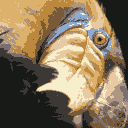

Ảnh nén bằng K-means của thư viện 


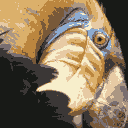

Ảnh gốc


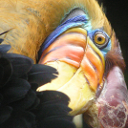

In [9]:
print('Ảnh nén bằng K-means tự viết')
display(Image('img_128.png', width=250, unconfined=True))#kết quả tự cài đặt
print('Ảnh nén bằng K-means của thư viện ')
display(Image('img128.png', width=250, unconfined=True)) #kết quả của thư viện
print('Ảnh gốc')
display(Image(path_img, width=250, unconfined=True))

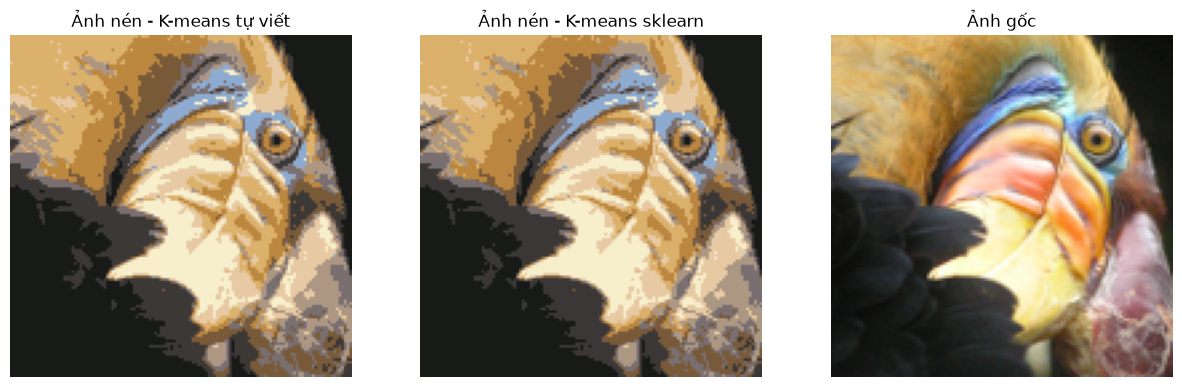

In [10]:
# So sánh trực quan 3 ảnh cạnh nhau
plt.figure(figsize=(15, 5))
for i, (title, im) in enumerate([("Ảnh nén - K-means tự viết", img_128),
                                 ("Ảnh nén - K-means sklearn", img128),
                                 ("Ảnh gốc", img)]):
    plt.subplot(1, 3, i + 1)
    plt.imshow(im)
    plt.title(title)
    plt.axis('off')
plt.show()